## Загрузка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('final_dataset.csv')
df = pd.DataFrame(data=data)

In [4]:
df['sex']

,sex
0,2.0
1,2.0
2,1.0
3,2.0
4,1.0
...,...
4593,2.0
4594,2.0
4595,1.0
4596,2.0


In [5]:
params = ['age', 'income', 'n_child', 'sex', 'type_area', 'invalid',
       'mar_st', 'visit_doctor', 'work', 'alcohol', 'smoking', 'phys_active',
       'is_health_good', 'is_health_very_good', 'diploma'] # разделим на параметры и на зависимые переменные
targets = df.keys().drop(params).to_list()

In [6]:
df[targets].sum() # так как они бинарные, сумма будет как раз выдавать их количество в полученной выборке.

,0
heart,214.0
lungs,259.0
liver,154.0
kidneys,198.0
stomach,724.0
spine,659.0
diabetes,282.0
hypertension,983.0
joints,684.0
ENT_organs,342.0


Дополнительно, стоит чуть разъяснить значения целевых переменных:

heart - Есть ли хронические заблевания сердца?  
lungs - Есть ли хронические заболевния легких, бронхов?  
liver - Есть ли хронические заболевания печени?  
kidneys - Есть ли хронические заболевания почек?  
stomach - Есть ли хронические заболевания ЖКТ?  
spine - Есть ли хронические заболевания позвоночника?  
diabetes - Есть ли хронические заболевания эндокринной системы, диабет или повышенный сахар в крови?  
hypertension - Есть ли хронические гипертоническая болезнь, повышенное артериальное давление?  
joints - Есть ли хронические заболевания суставов?  
ENT_organs - Есть ли хронические заболевания ЛОР-органов?  
neurology - Есть ли хронические неврологические заболевания?  
eyes - Есть ли хронические заболевания глаз?  
allergy - Есть ли хроническая аллергия?  
veins - Есть ли варикозное расшиерние вен?  
skin - Есть ли хронические заболевания кожного покрова?  
oncology - Есть ли хронические онкологические заболевания?  

### Приступаем!

In [33]:
print("Информация о датафрейме:")
df.info()

print("\nОписательные статистики (чисто для приличия):")
display(df.describe())

print(df.shape)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4598 entries, 0 to 4597
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   heart                4598 non-null   float64 
 1   lungs                4598 non-null   float64 
 2   liver                4598 non-null   float64 
 3   kidneys              4598 non-null   float64 
 4   stomach              4598 non-null   float64 
 5   spine                4598 non-null   float64 
 6   diabetes             4598 non-null   float64 
 7   hypertension         4598 non-null   float64 
 8   joints               4598 non-null   float64 
 9   ENT_organs           4598 non-null   float64 
 10  neurology            4598 non-null   float64 
 11  eyes                 4598 non-null   float64 
 12  allergy              4598 non-null   float64 
 13  veins                4598 non-null   float64 
 14  skin                 4598 non-null   float64 
 

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
count,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,...,4598.000000,4598.000000,4598.000000,4598.0,4598.00000,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000
mean,0.046542,0.056329,0.033493,0.043062,0.157460,0.143323,0.061331,0.213789,0.148760,0.074380,...,0.018704,0.787734,0.497390,1.0,0.69204,0.289909,0.224663,0.444976,0.011962,0.387777
std,0.210679,0.230581,0.179939,0.203019,0.364273,0.350440,0.239963,0.410024,0.355891,0.262417,...,0.135491,0.408957,0.500048,0.0,0.46170,0.453769,0.417406,0.497017,0.108725,0.487296
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,1.0,1.00000,1.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


(4598, 32)


На самом деле, эти статистики нам много не дадут, только у средних есть смысл, также, можно посмотреть на эти статистики для дохода и возраста. В остальном, бинарность нам много выводов сделать сразу же не позволяет.

In [29]:
print("Количество пропущенных значений по столбцам:")
display(df.isnull().sum()) # вроде бы все ок, соответствует изначальной очистке.

Количество пропущенных значений по столбцам:


,0
heart,0
lungs,0
liver,0
kidneys,0
stomach,0
spine,0
diabetes,0
hypertension,0
joints,0
ENT_organs,0


## Базовые распределения



### Распределение числовых признаков

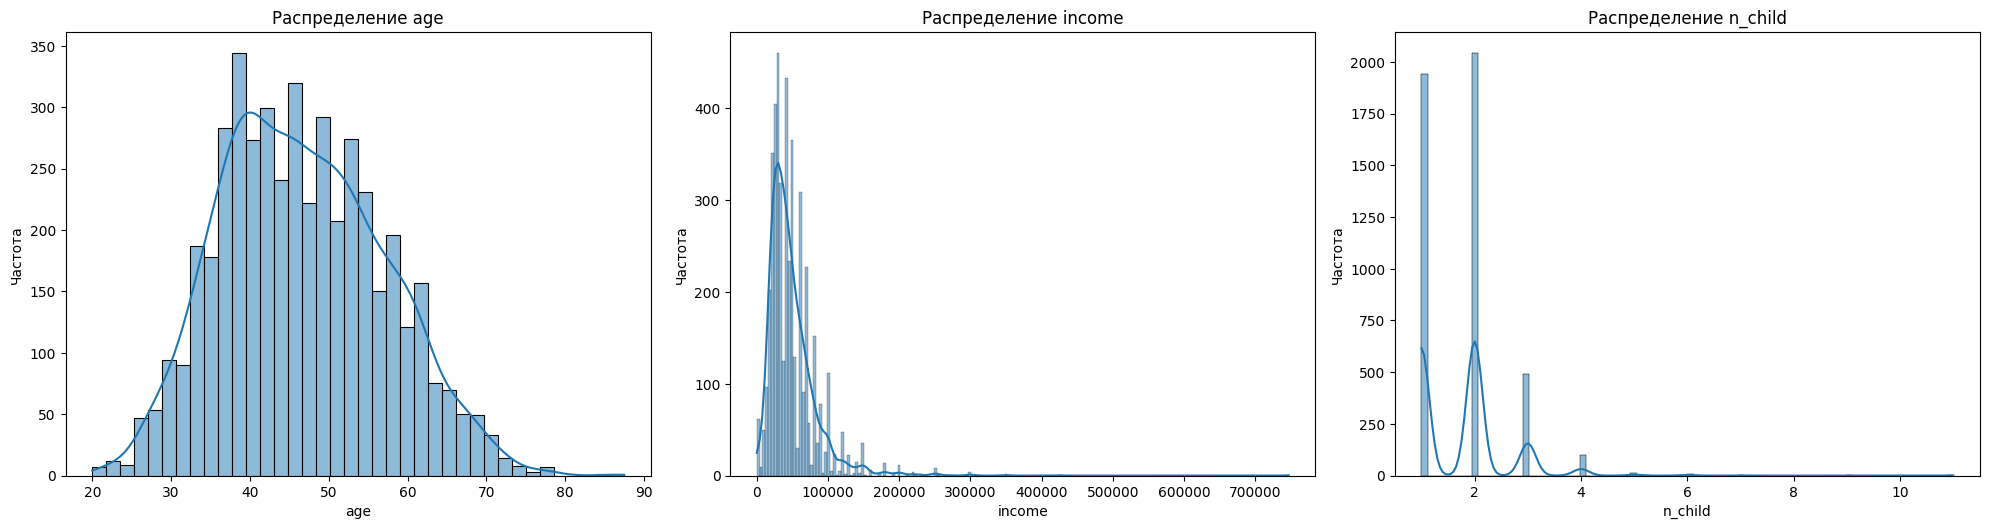

In [24]:
numerical_params = ['age', 'income', 'n_child']

plt.figure(figsize=(20, 15))
for i, param in enumerate(numerical_params):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[param], kde=True)
    plt.title(f'Распределение {param}')
    plt.xlabel(param)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Как будто бы статистическая осмысленность в них есть, по крайней мере, возраст похож на нормальное распределение, у дохода, как всегда, тяжелый хваст справа, и количество детей явно говорит нам о печальном тренде в российской демографии...

### Распределение категориальных признаков

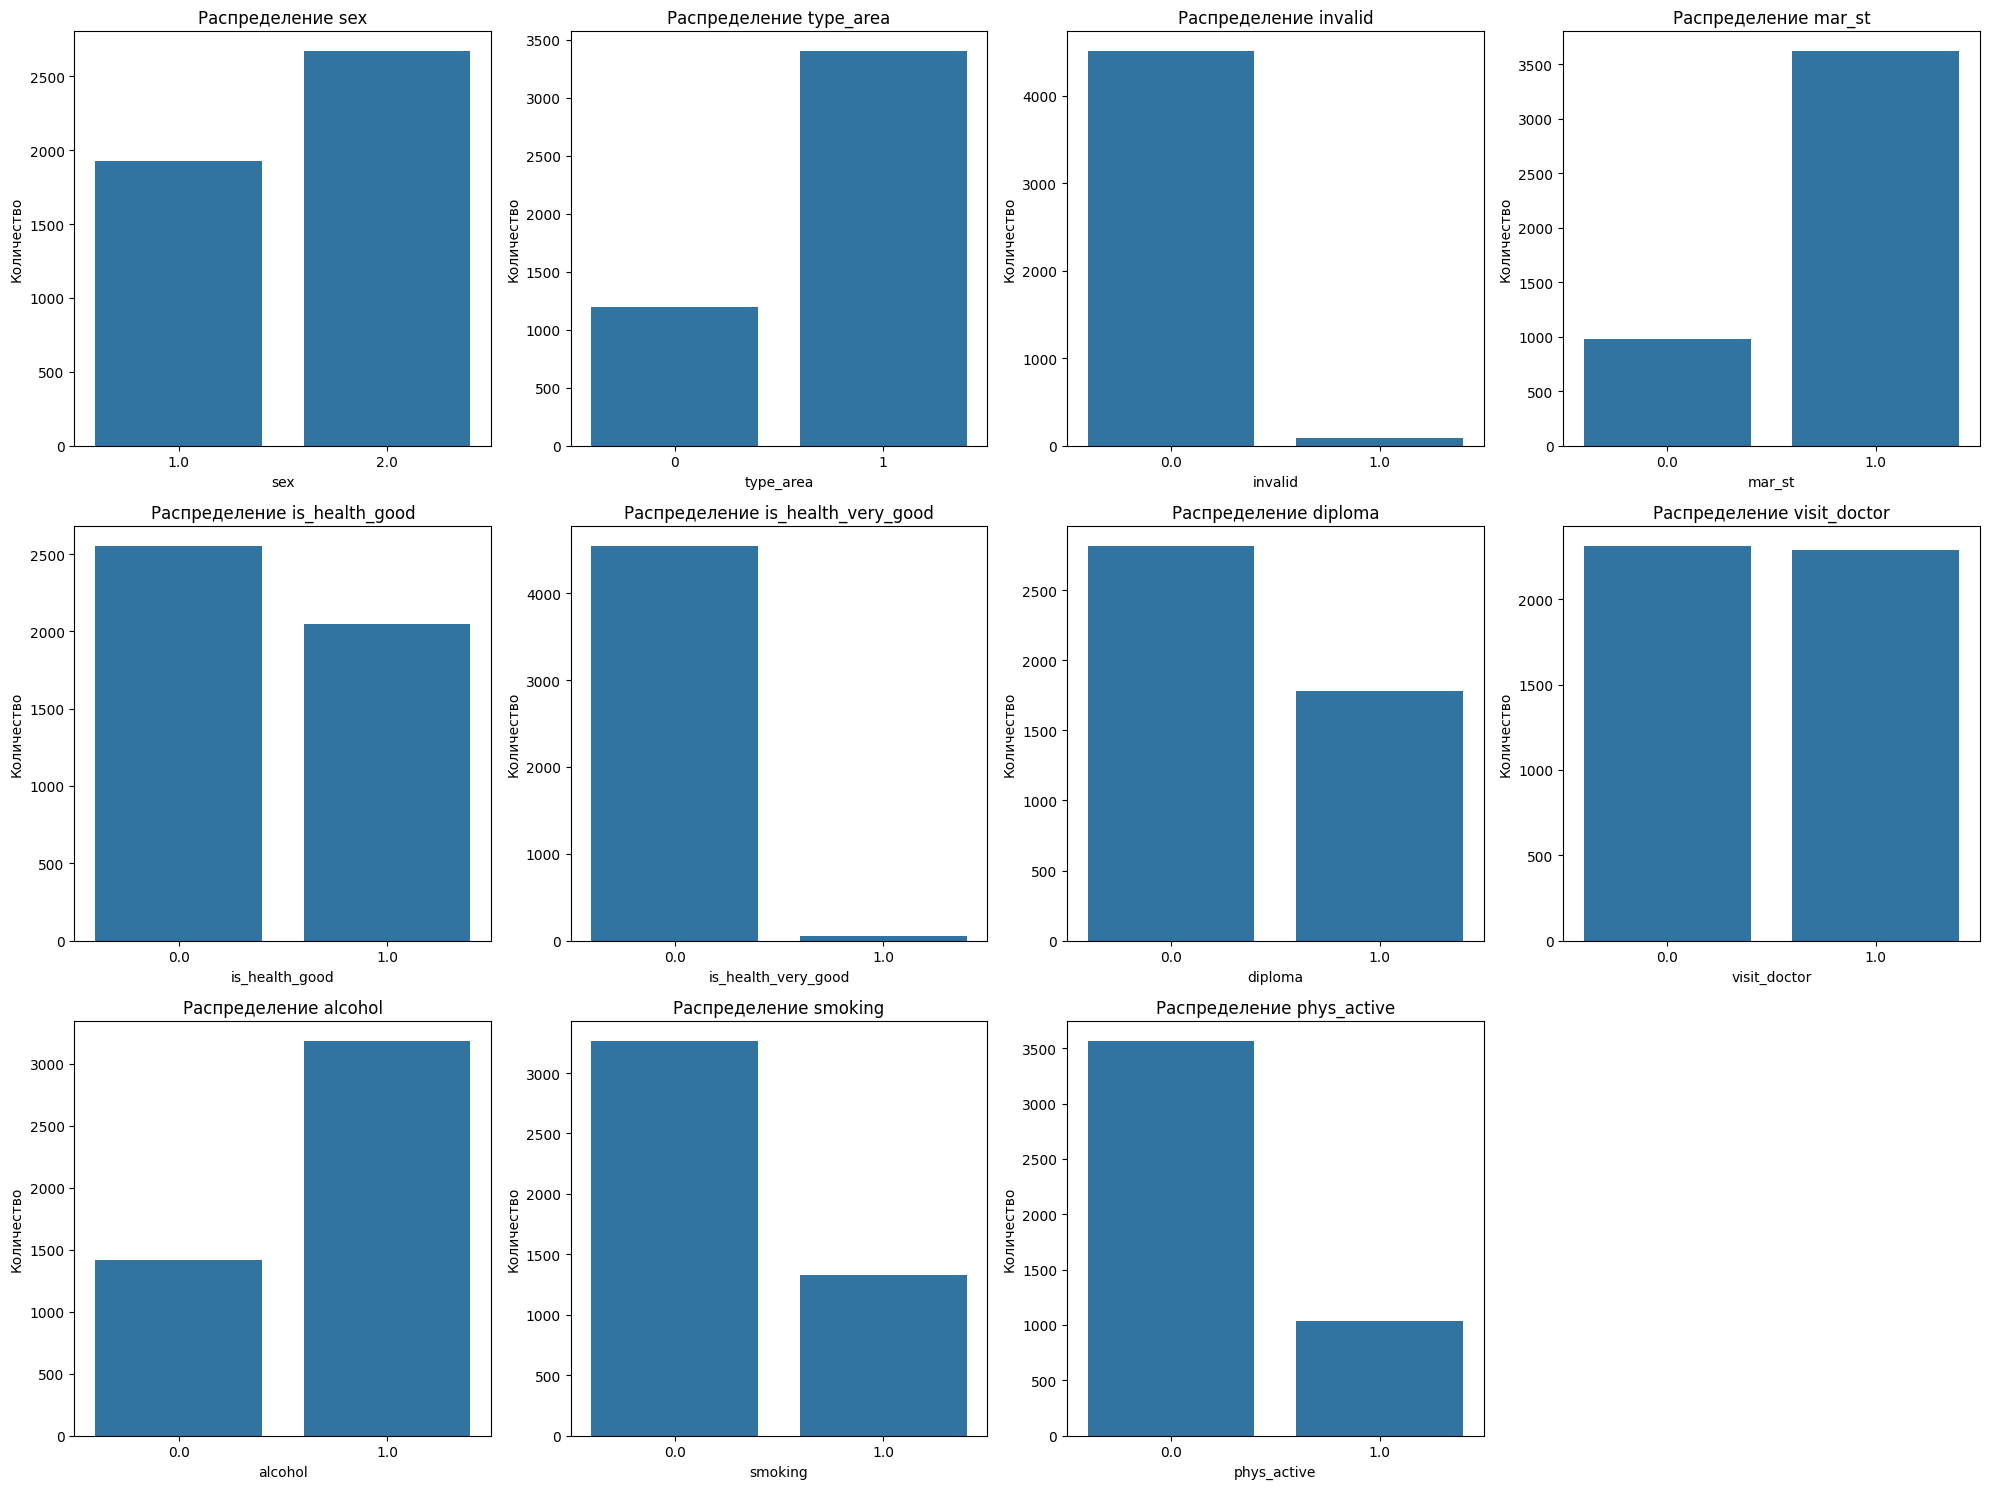

In [28]:
categorical_params = ['sex', 'type_area', 'invalid', 'mar_st', 'is_health_good', 'is_health_very_good', 'diploma', 'visit_doctor', 'alcohol', 'smoking', 'phys_active']

plt.figure(figsize=(20, 15))
for i, param in enumerate(categorical_params):
    plt.subplot(3, 4, i + 1)
    sns.countplot(x=df[param])
    plt.title(f'Распределение {param}')
    plt.xlabel(param)
    plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Интересно, стесняются ли все говорить, что у них отличное здоровье, и все дело в формате опроса и в том как он "фреймит" респондентов, или действительно у людей не может быть отличного здоровья. В остальном - все довольно ожидаемо и реалистично, как мне кажется.

Важно подсветить, что есть гендерное смещение, поэтому по всей совокупности сразу довольно трудно работать, вполне разумно последовать за логикой в статье, и рассматривать каждый пол как отдельную группу. Благо, размер выборки это пока что позволяет сделать, даже с учетом того, что многие значения уже были выброшены при первичной обработке данных. Плюс это важно, так как такие доли по полу не соотносятся с генеральной совокупностью россиян. Остальные значения на первый взгляд выглядят довольно реалистично.

### Распространенность заболеваний



Для начала стоит посмотреть, как часто каждое из заболеваний вообще встречается.

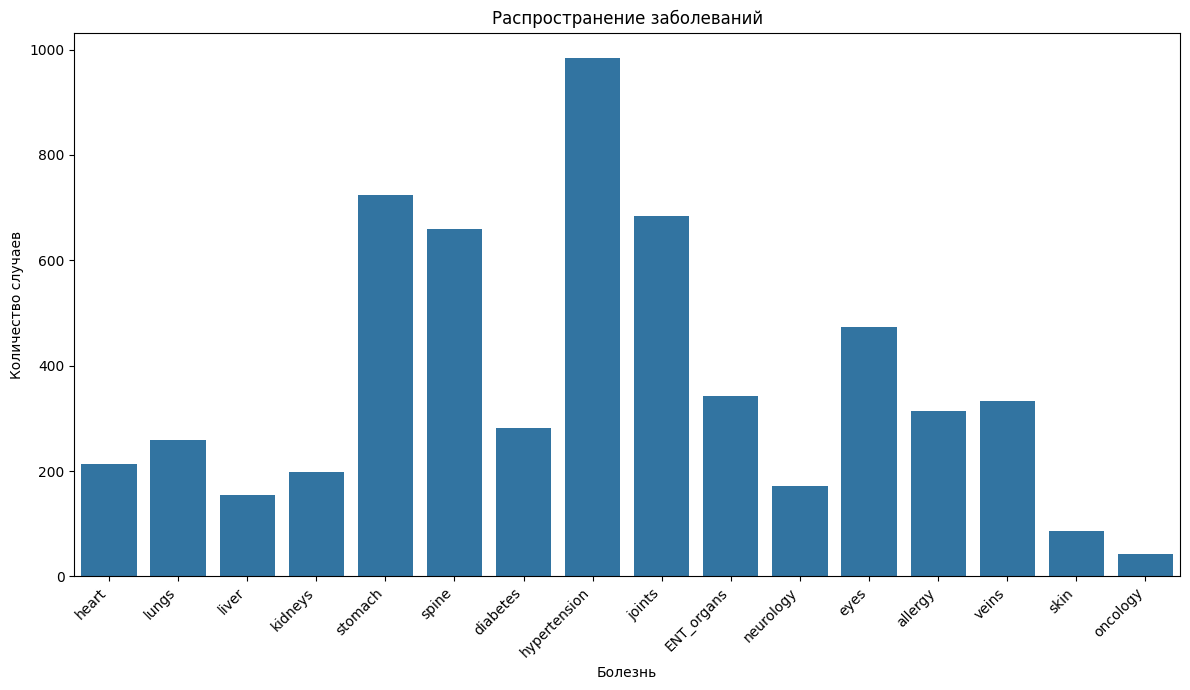

In [7]:
disease_counts = df[targets].sum()

plt.figure(figsize=(12, 7))
sns.barplot(x=disease_counts.index, y=disease_counts.values)
plt.title('Распространение заболеваний')
plt.xlabel('Болезнь')
plt.ylabel('Количество случаев')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Довольно неожиданно на первый взгляд. Насколько я помню, основная причина смерти, чаще всего, это сердечная недостаточность. Видимо, мои представления о медицине были ошибочны, и проблемы с давлением (сосудистые?) - это тоже одна из причин той же смертности. Иначе не знаю с чем это связать. Ну, видимо, с возрастом и суставы, и сосуды, и позвоночник изнашиваются. А ЖКТ - общая постоянная проблема. Как и зрение, особенно в контексте постоянной необходимости взаимодействовать с мелким текстом, двигающимися объектами и т.п.

Онкология, конечно, меньше всех представлена. Это, вероятно, либо из-за повышенной смертности, то есть что с раком долго не прожить, либо из-за того, что это не самые распространенные заболевания. Я, к сожалению, склоняюсь все же к первому варианту.

Дополнительно, построим корреляционную матрицу и посмотрим, какие пары болячек чаще всего встречаются в совокупности. Идут, так сказать, букетом.

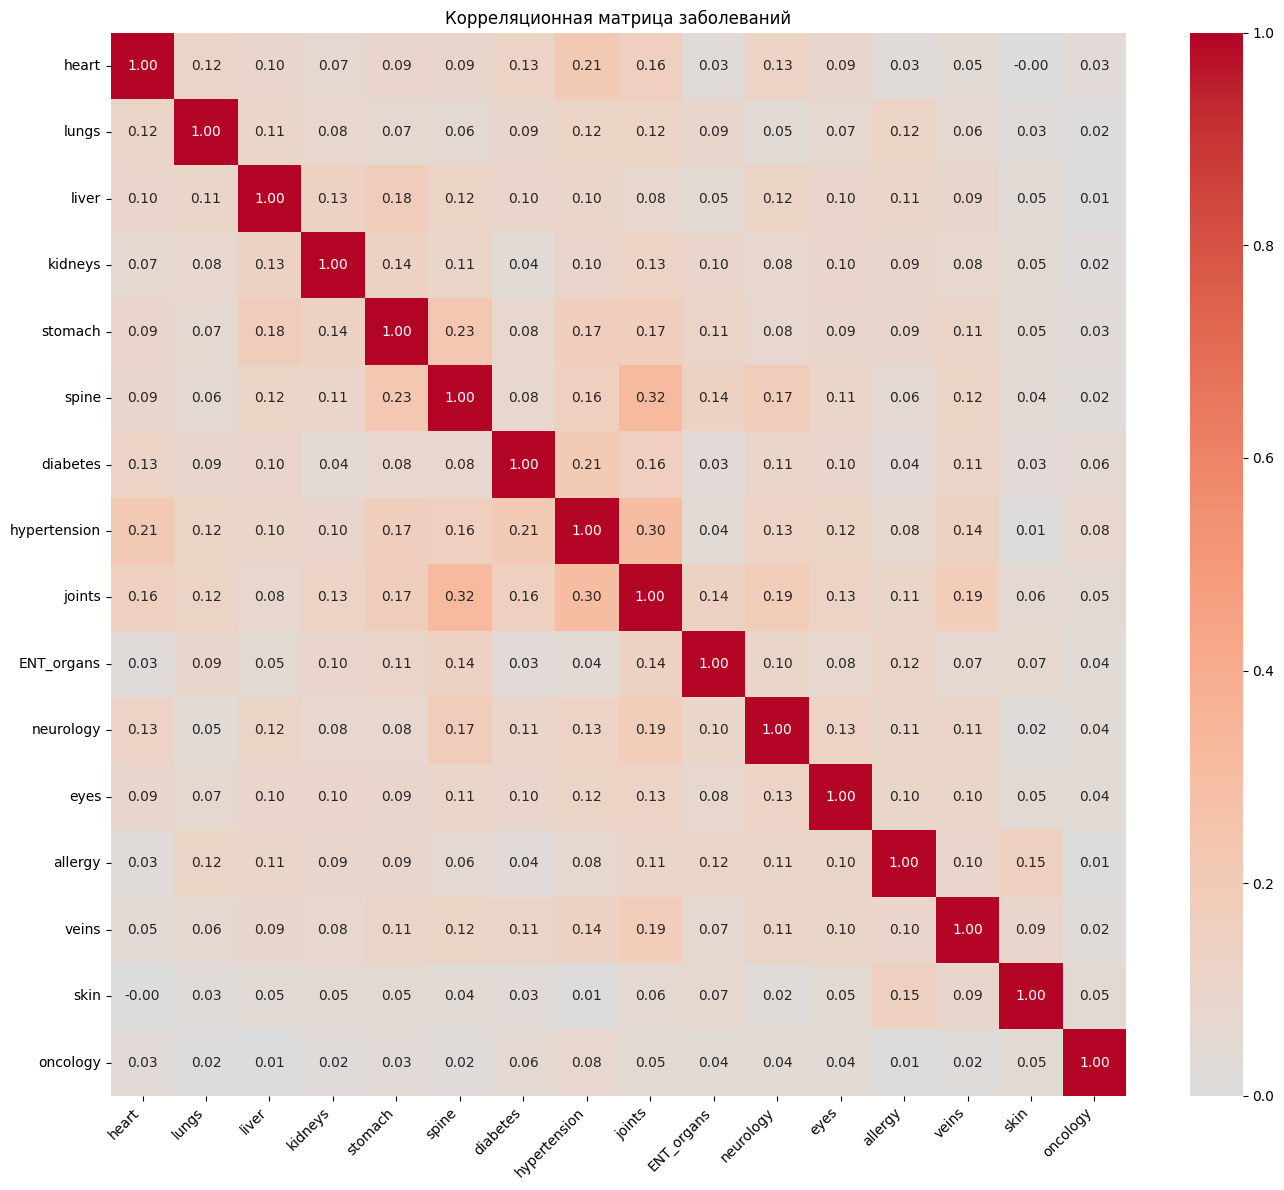

In [8]:
correlation_matrix = df[targets].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Корреляционная матрица заболеваний')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Думаю, следует подсветить лишь те корреляции, где значение хотя бы выше 0.3: в частности, это корреляция между заболеваниями суставов и заболеваниями позвоночника; также, между заболеваниями суставов и повышенным артериальным давлением.

Спешу предположить, что это, вероятнее всего связано с тем, что это сильно возрастные заболевания, и взаимосвязь в первую очередь возникает именно из-за возрастных показателей респондентов. Чуть подробнее посмотрим на это при дальнейшем анализе.

## Поверхностное исследование взаимосвязей

### Посмотрим на взаимосвязи с полом

Сейчас пронаблюдаем, какая доля в завимисоти от пола, с какими заболеваниями чаще встречаемся.

In [9]:
disease_prevalence_by_sex = df.groupby('sex')[targets].mean()
disease_prevalence_by_sex

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,neurology,eyes,allergy,veins,skin,oncology
sex,,,,,,,,,,,,,,,,
1.0,0.053479,0.050363,0.034787,0.028037,0.149013,0.143821,0.036864,0.191589,0.127207,0.056075,0.030633,0.074766,0.049844,0.033749,0.017653,0.003634
2.0,0.041542,0.060629,0.032560,0.053892,0.163548,0.142964,0.078967,0.229790,0.164296,0.087575,0.041916,0.123503,0.081587,0.099925,0.019461,0.013473


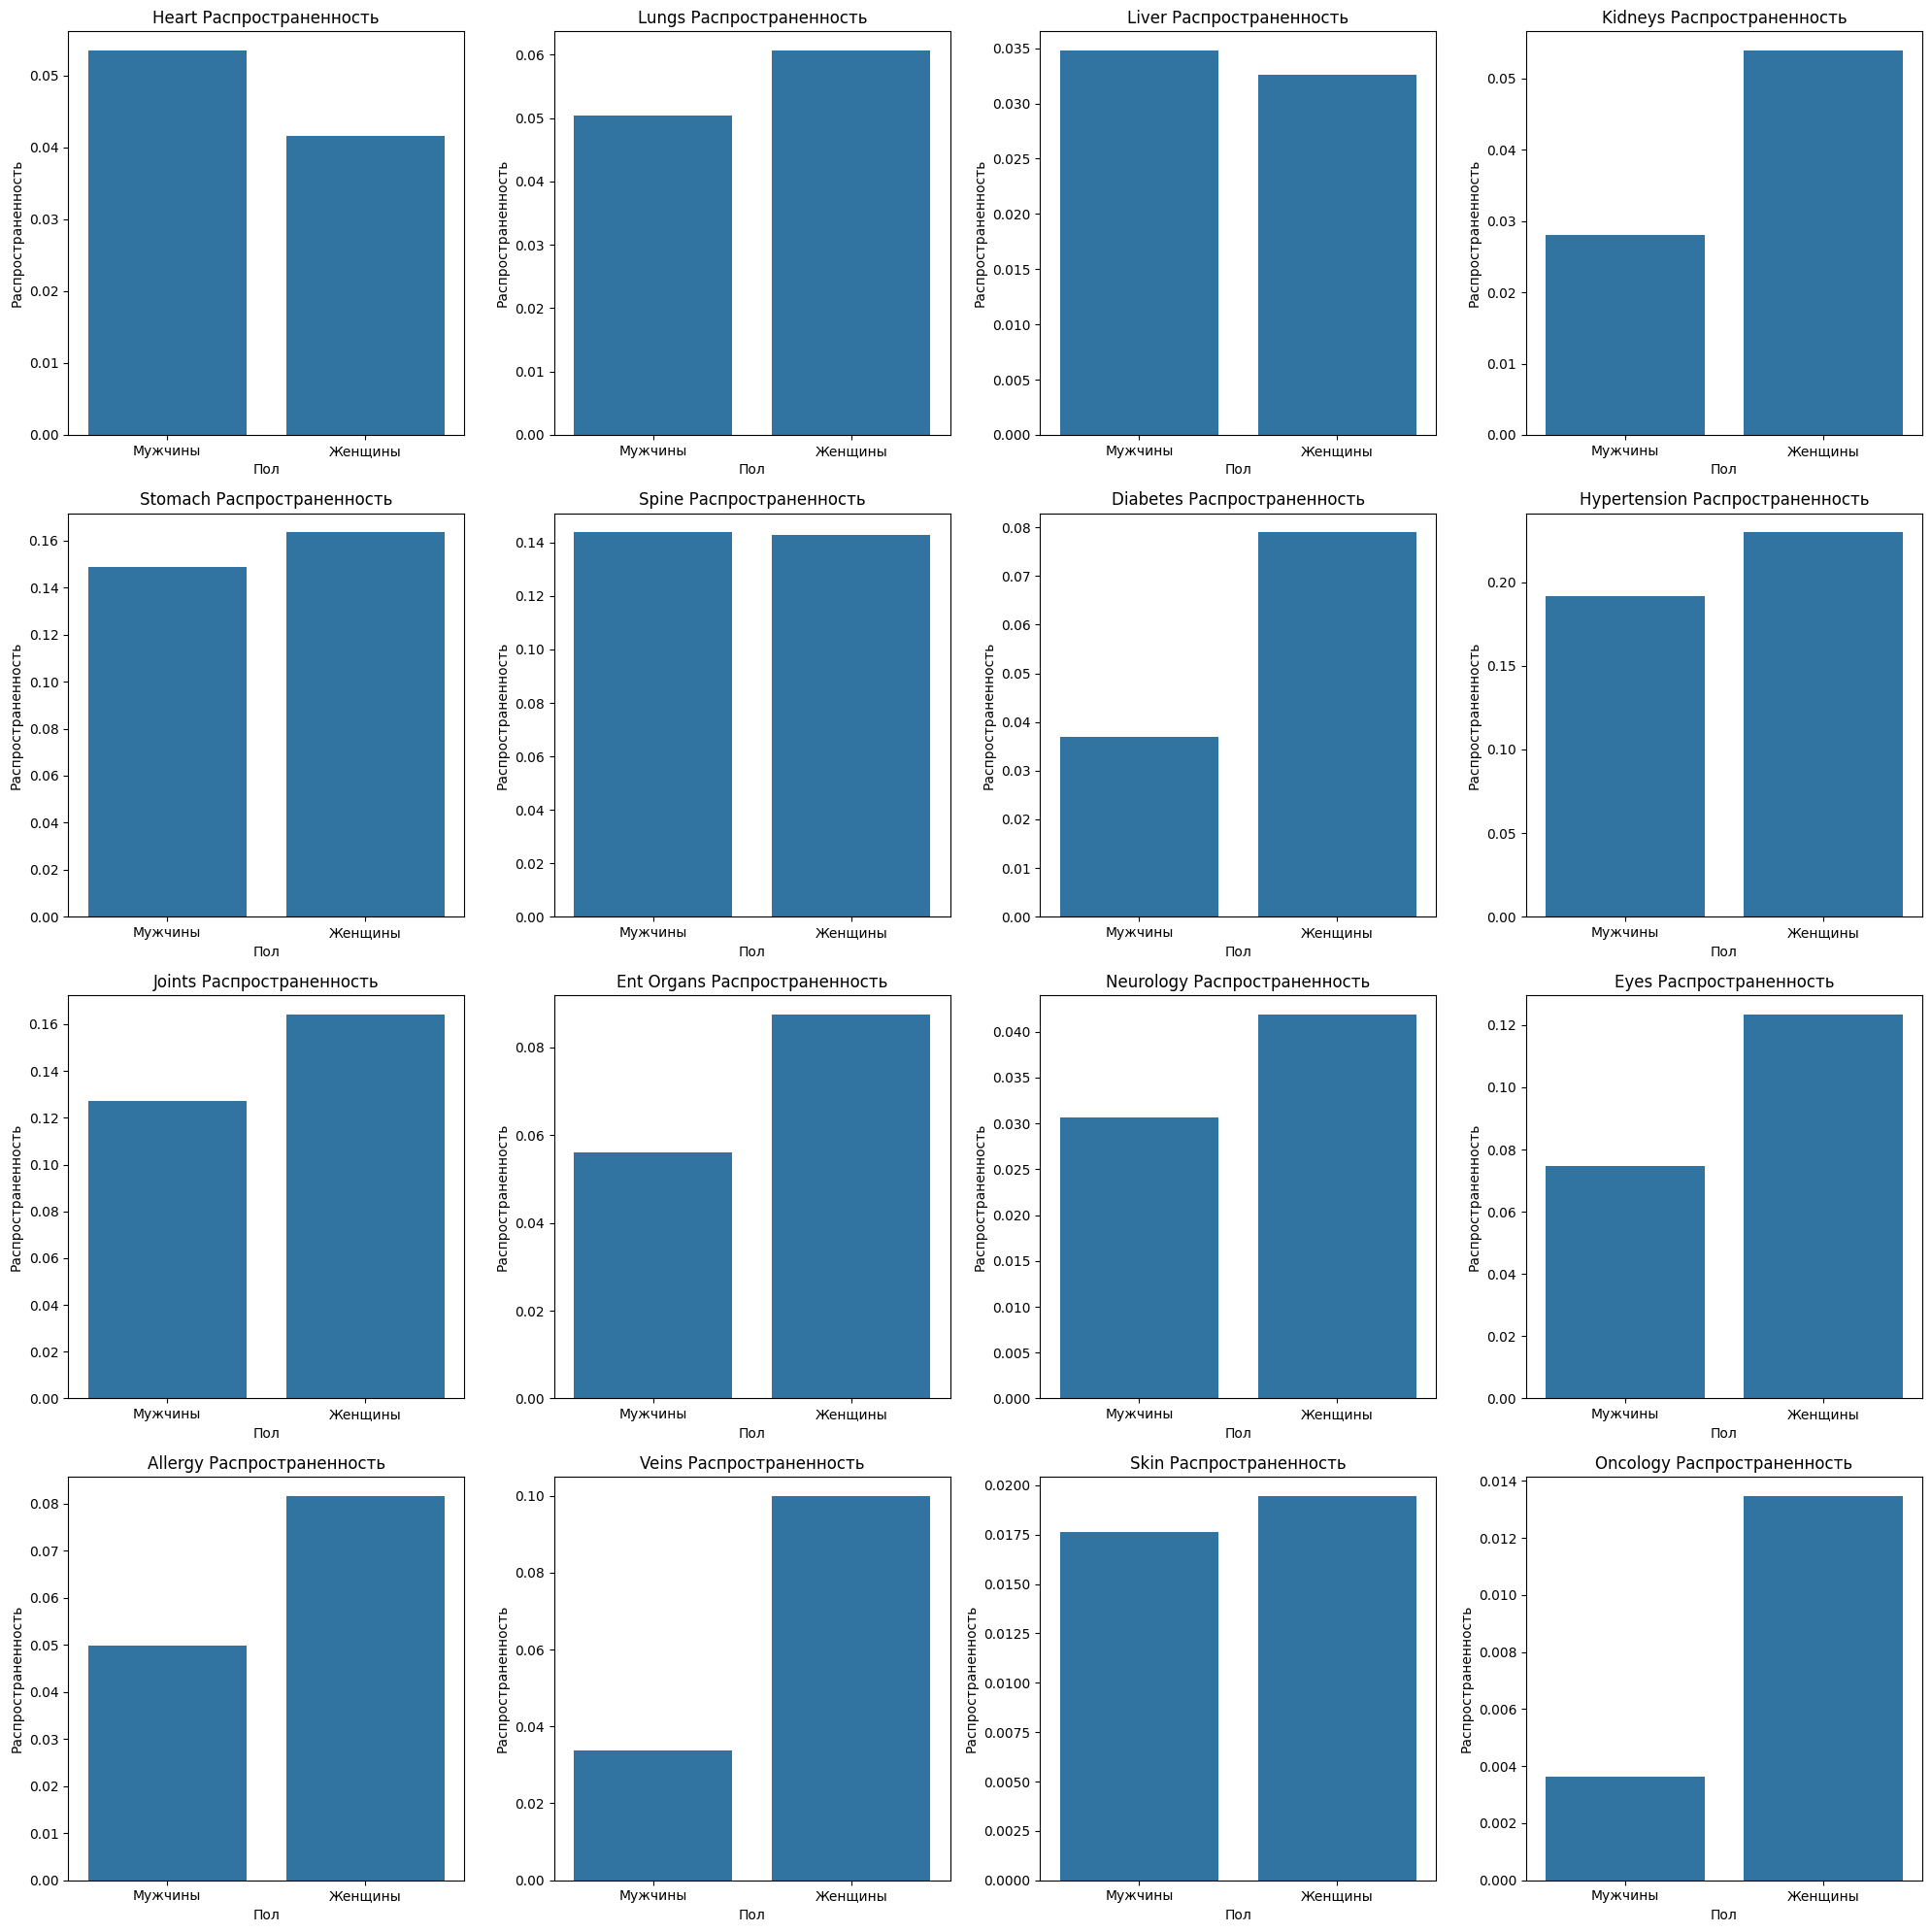

In [10]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, disease in enumerate(targets):
    sns.barplot(x=disease_prevalence_by_sex.index, y=disease_prevalence_by_sex[disease].values, ax=axes[i])
    axes[i].set_title(f'{disease.replace("_", " ").title()} Распространенность')
    axes[i].set_xlabel('Пол')
    axes[i].set_ylabel('Распространенность')
    axes[i].set_xticks([0, 1], ['Мужчины', 'Женщины'])

plt.tight_layout()
plt.show()

По всем категориям, кроме сердечных, заболеваний печени и заболеваний позвоночника - в большинстве случаев заболевания именно у женщин.

Существует подозрение на определенного рода самоотбор: так как тут не абсолютные показатели, а именно доли по каждому из полов, велика вероятность, что проблема не в том, что женщины чаще болеют, а именно в том, что они активнее следят за своим здоровьем и, соответственно, лучше обнаруживают хронические заболевания. Те заболевания, которые обнаруживают чаще у мужчин, вероятно, относятся к тем заболеваниям, которые игнорировать уже невозможно: логично предположить, что человек с больной спиной будет лучше замечать свою болезнь, чем, скажем, онкобольной.

### Распространенность в зависимости от наличия диплома

In [11]:
disease_prevalence_by_diploma = df.groupby('diploma')[targets].mean()
disease_prevalence_by_diploma

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,neurology,eyes,allergy,veins,skin,oncology
diploma,,,,,,,,,,,,,,,,
0.0,0.046536,0.068917,0.035879,0.047247,0.161634,0.158437,0.063588,0.225577,0.161989,0.075311,0.034103,0.092007,0.061812,0.075666,0.015986,0.009236
1.0,0.046551,0.036455,0.029725,0.036455,0.150869,0.119462,0.057768,0.195177,0.127874,0.072911,0.042064,0.120583,0.078519,0.066741,0.022995,0.009534


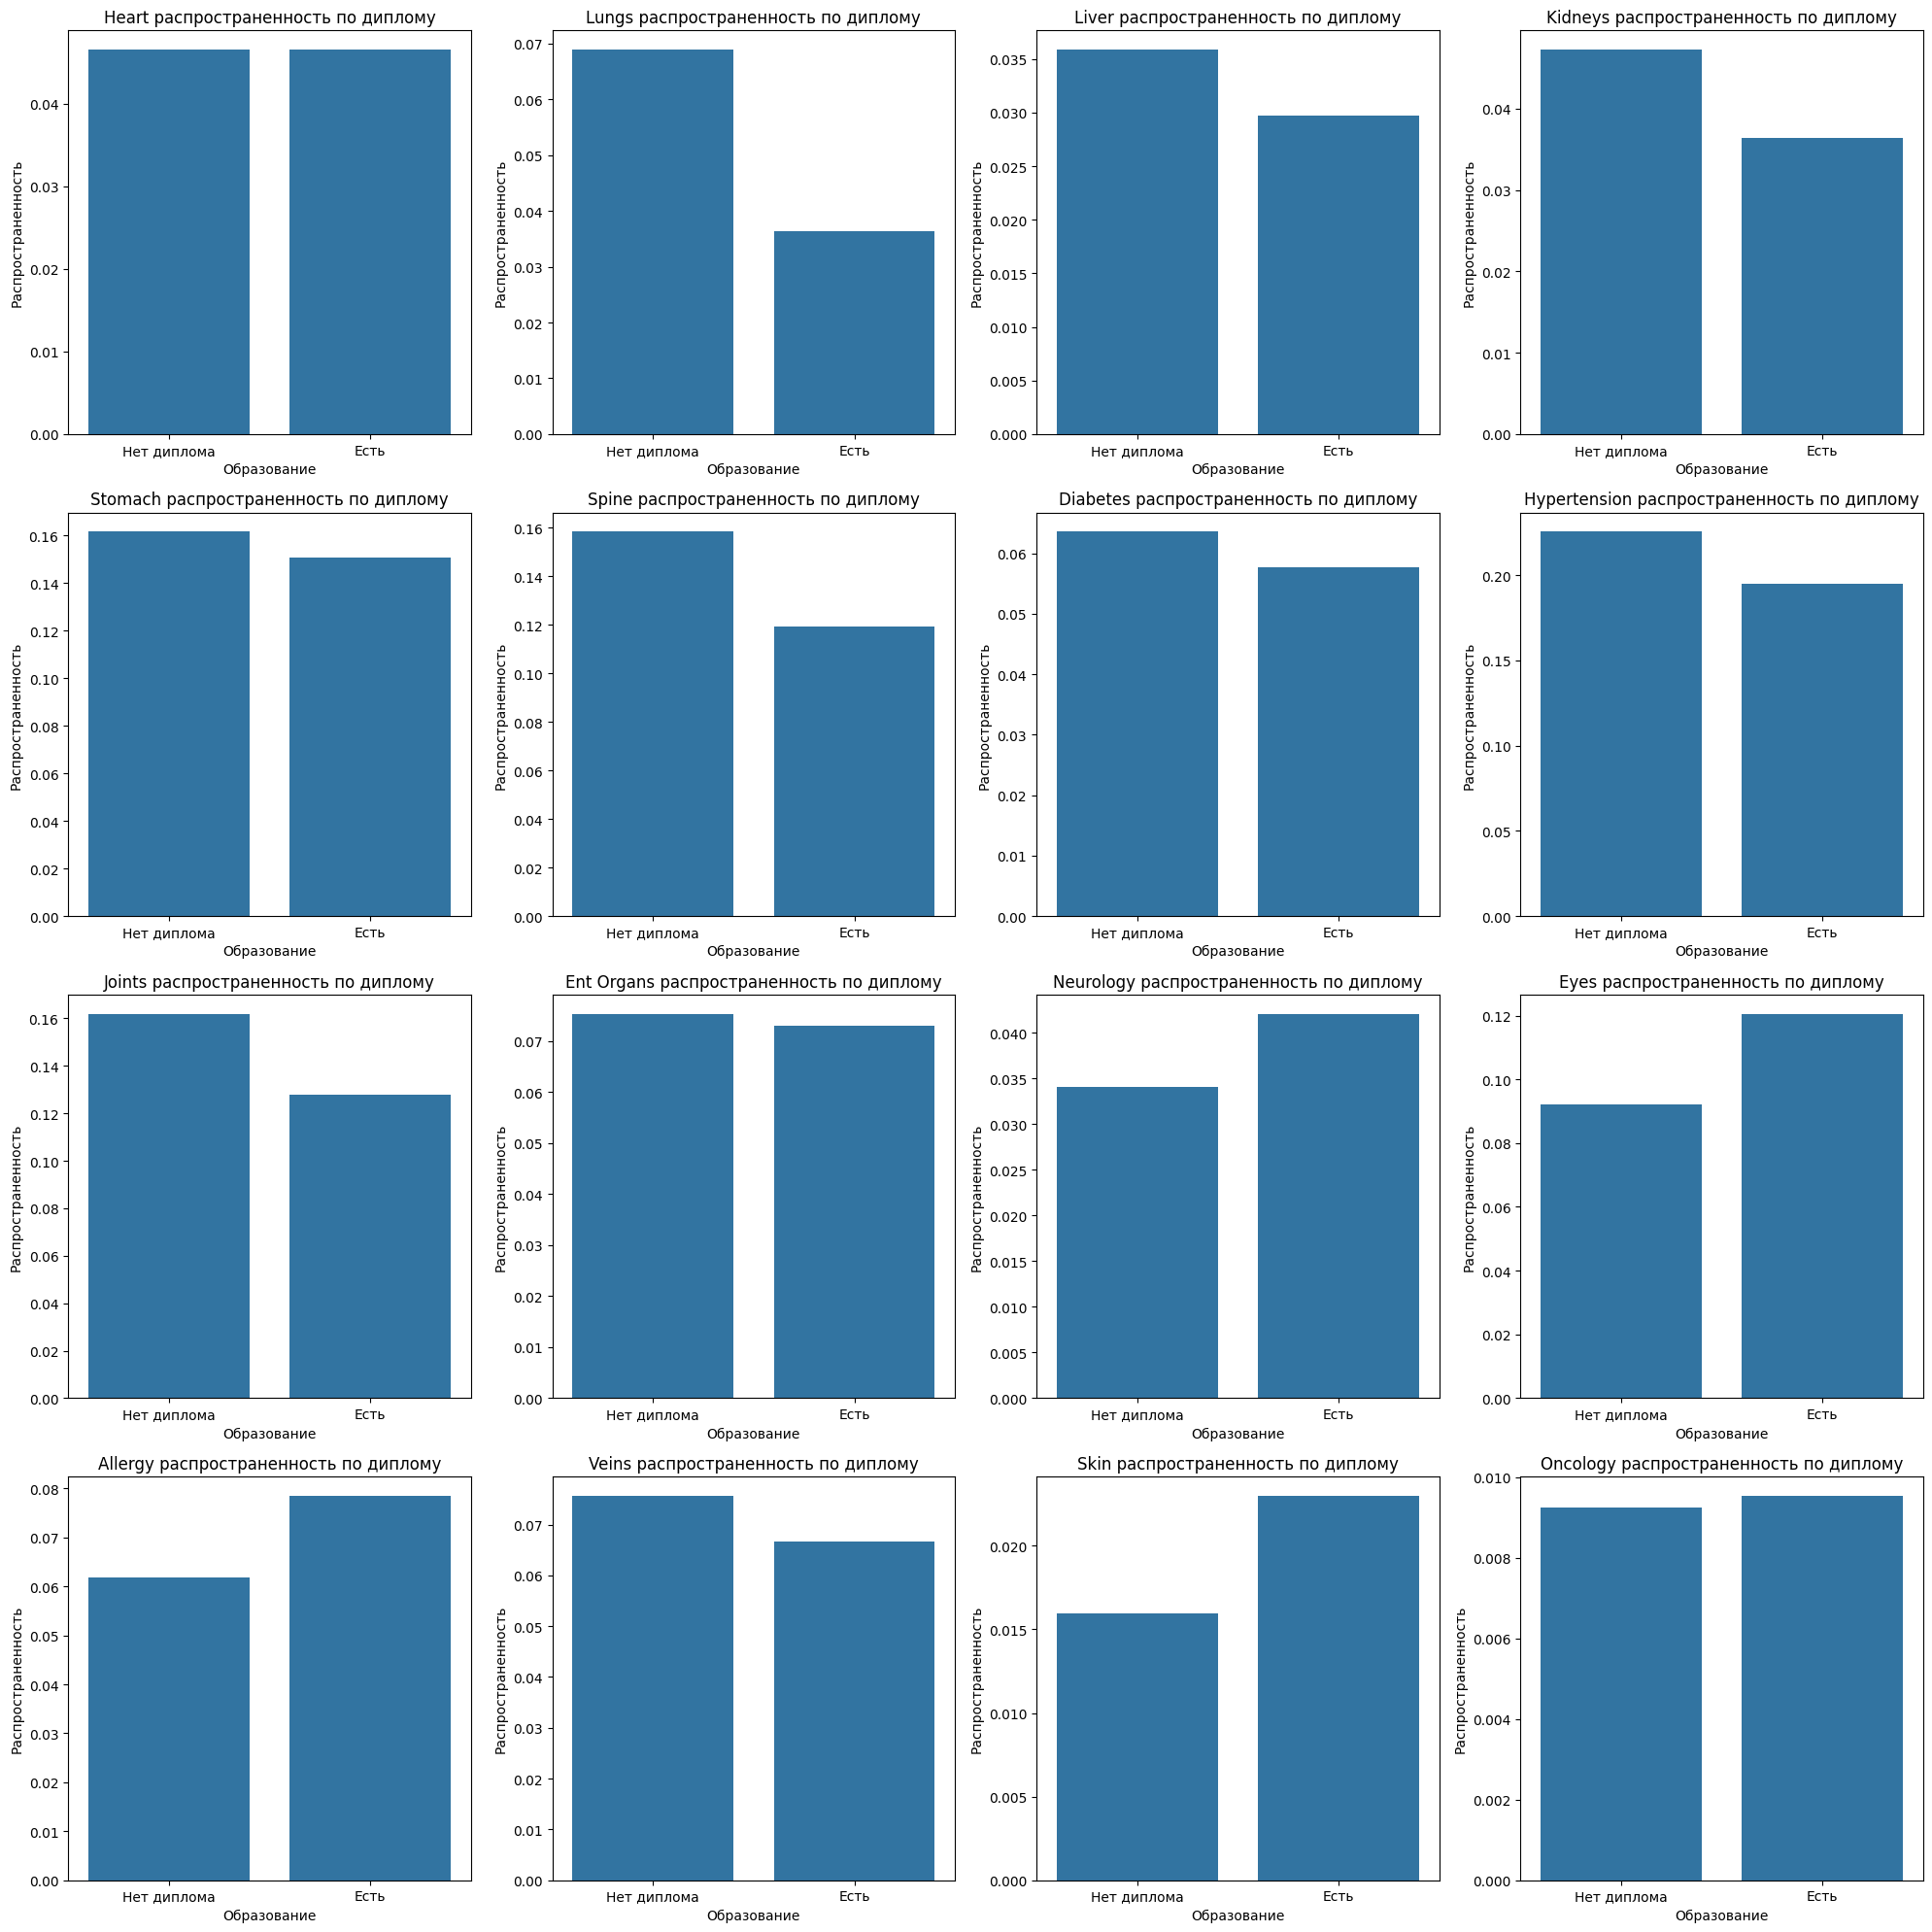

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, disease in enumerate(targets):
    sns.barplot(x=disease_prevalence_by_diploma.index, y=disease_prevalence_by_diploma[disease].values, ax=axes[i])
    axes[i].set_title(f'{disease.replace("_", " ").title()} распространенность по диплому')
    axes[i].set_xlabel('Образование')
    axes[i].set_ylabel('Распространенность')
    axes[i].set_xticks([0, 1], ['Нет диплома', 'Есть'])

plt.tight_layout()
plt.show()

Здесь трудно отмечать какие-то ярковыраженные взаимосвязи. Поверхностное рассмотрение указывает на то, что в целом, наличие диплома скорее снижает вероятность заболеваний. Видимо, из-за более высокого уровня ответственности за собственное здоровье. С другой стороны, можно предположить, что у людей с высшим образованием будет и более высокий уровень обнаруживаемости заболеваний.

В общем, этой информации пока что недостаточно, и нужно строить отдельные гипотезы и проверять их, чтобы более уверенно что-то можно было констатировать.

### Распространенность по возрастам

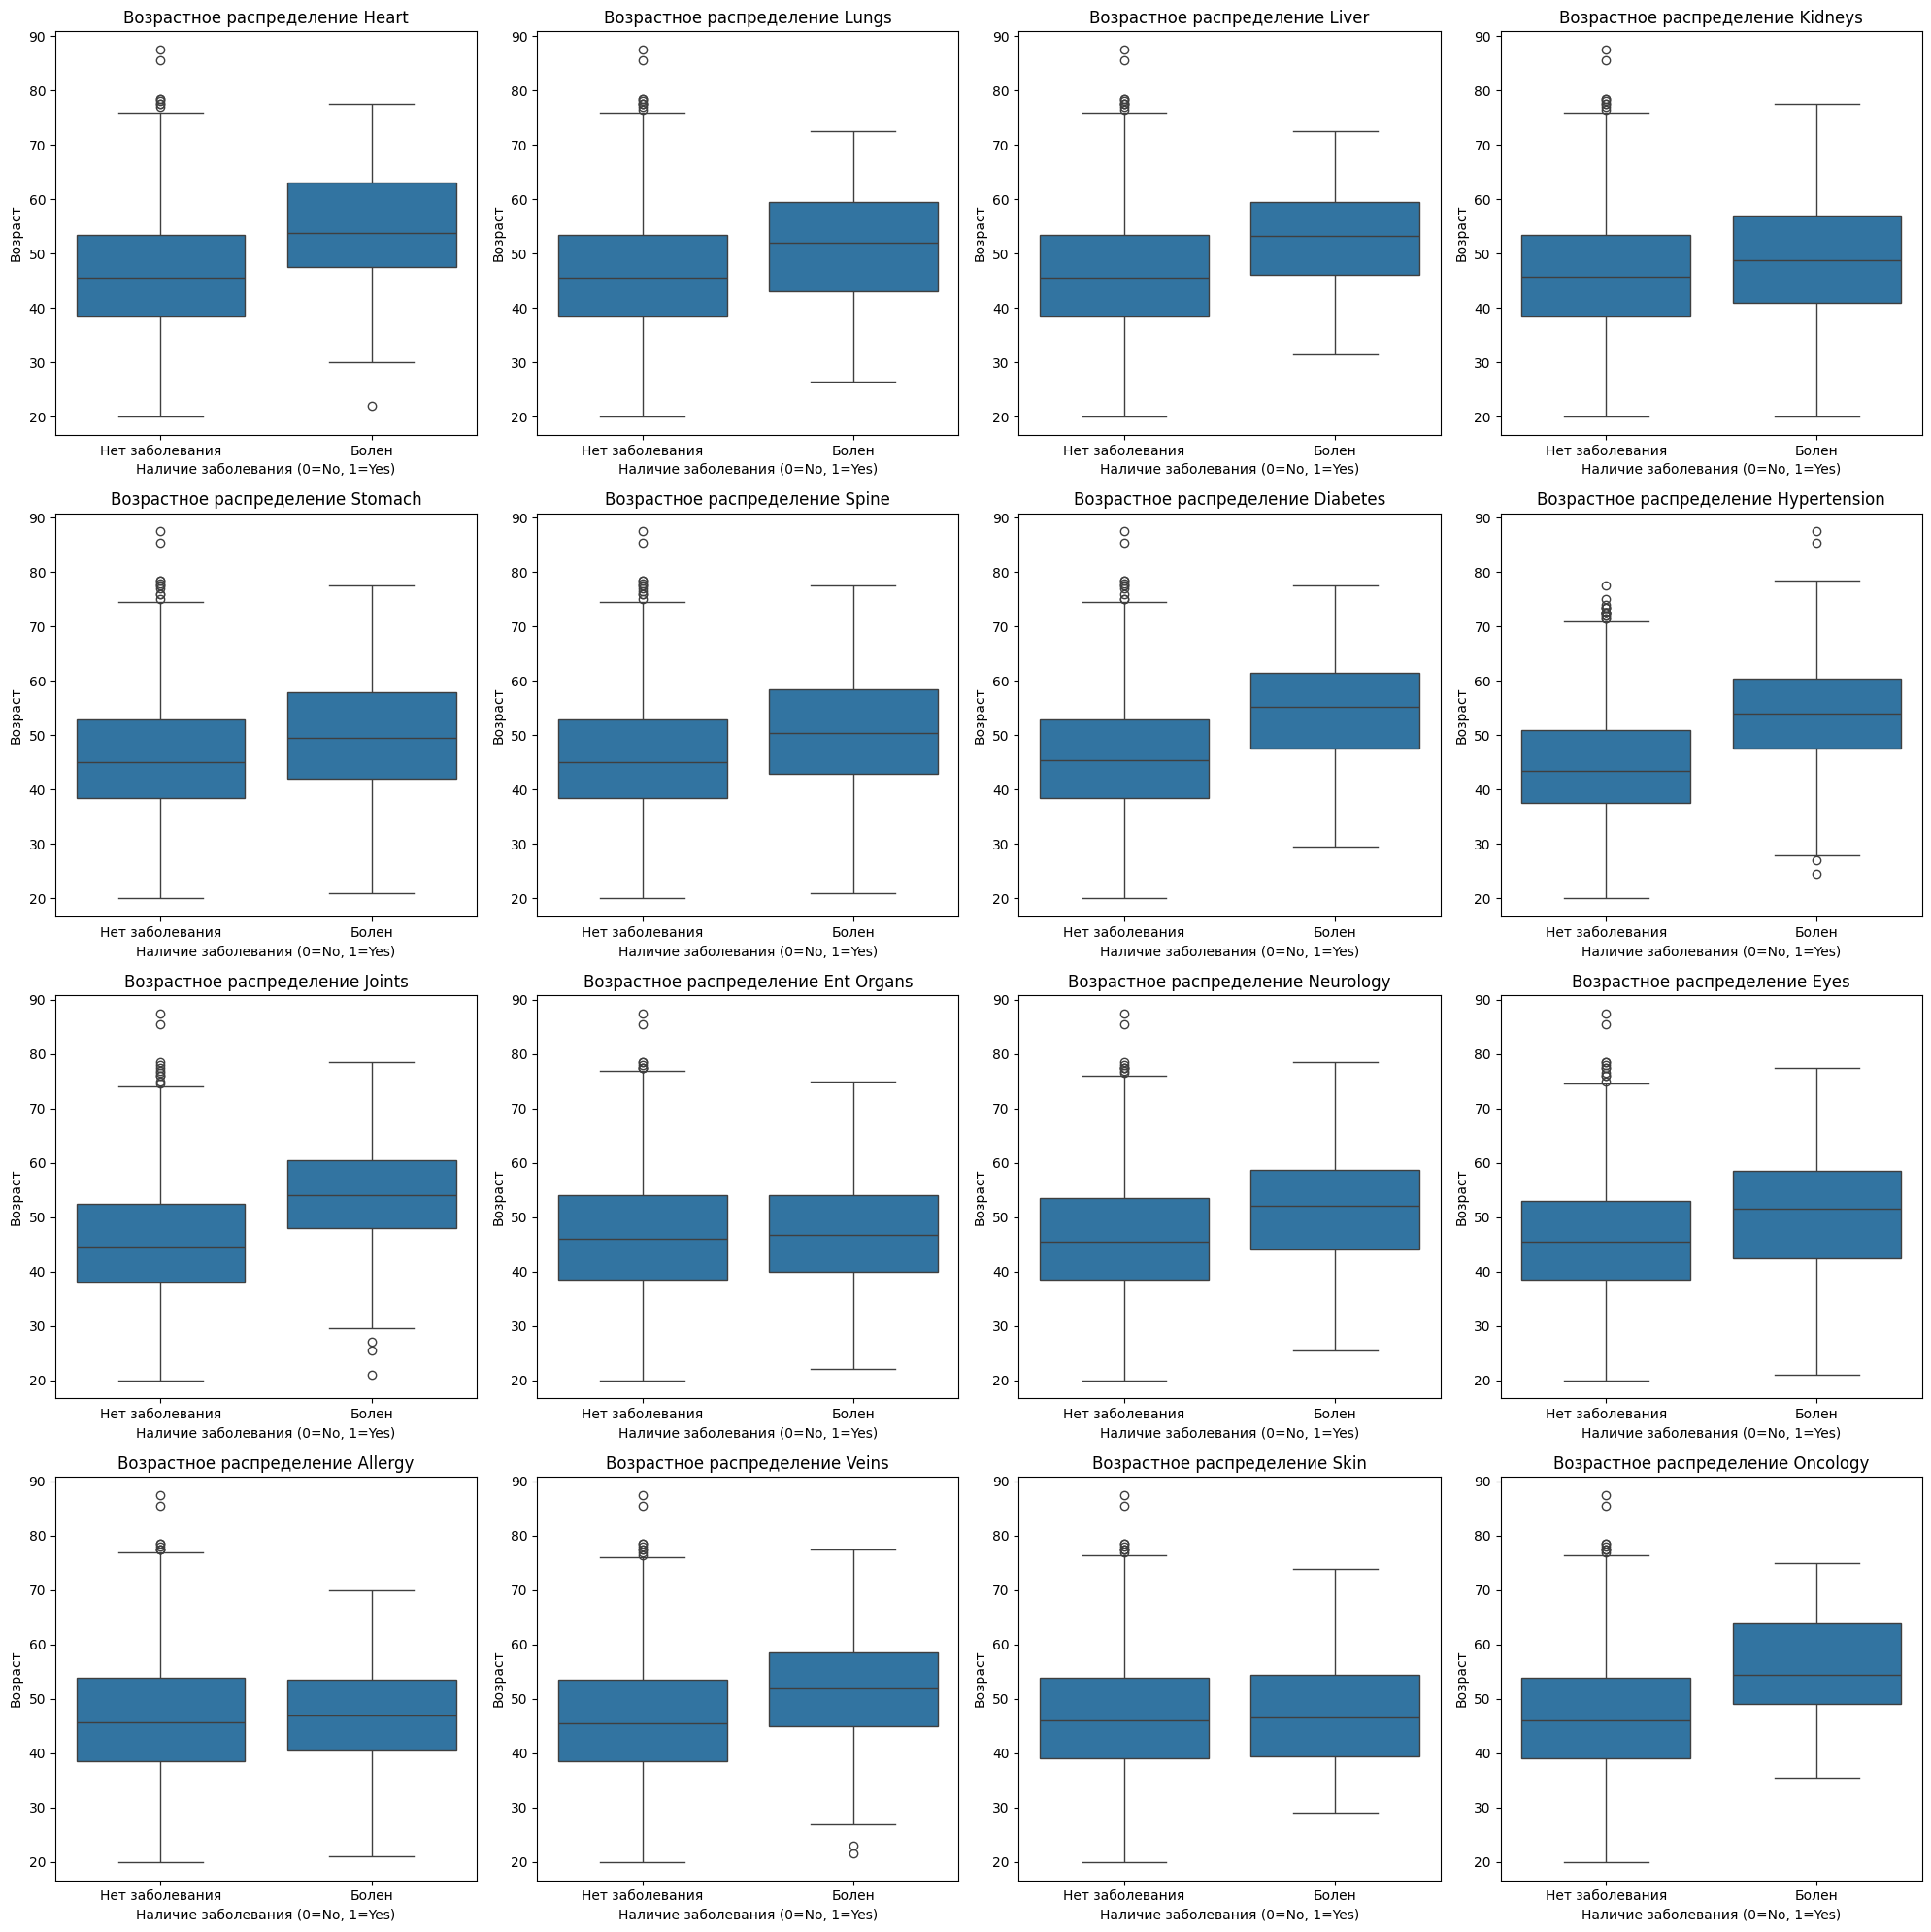

In [21]:
fig_age, axes_age = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes_age = axes_age.flatten()

for i, disease in enumerate(targets):
    sns.boxplot(x=df[disease], y=df['age'], ax=axes_age[i])
    axes_age[i].set_title(f'Возрастное распределение {disease.replace("_", " ").title()}')
    axes_age[i].set_xlabel('Наличие заболевания (0=No, 1=Yes)')
    axes_age[i].set_ylabel('Возраст')
    axes_age[i].set_xticks([0, 1], ['Нет заболевания', 'Болен'])

plt.tight_layout()
plt.show()

Видно, что многие заболевания, конечно, возрастные. Особенно заметно как раз с суставами и артериальным давлением, у которых мы ранее подметили высокую скоррелированность. Скорее всего, наше предположение могло действительно оказаться верным. Из интересного: заболевания кожи, лор-органов и кожи выглядят наименее зависящими от возраста. Вероятно, потому что они либо раньше всего проявляются, либо потому что они сильнее других зависят от генетической предрасположенности и проявляются хронически еще с раннего возраста.

### Распространенность по доходам

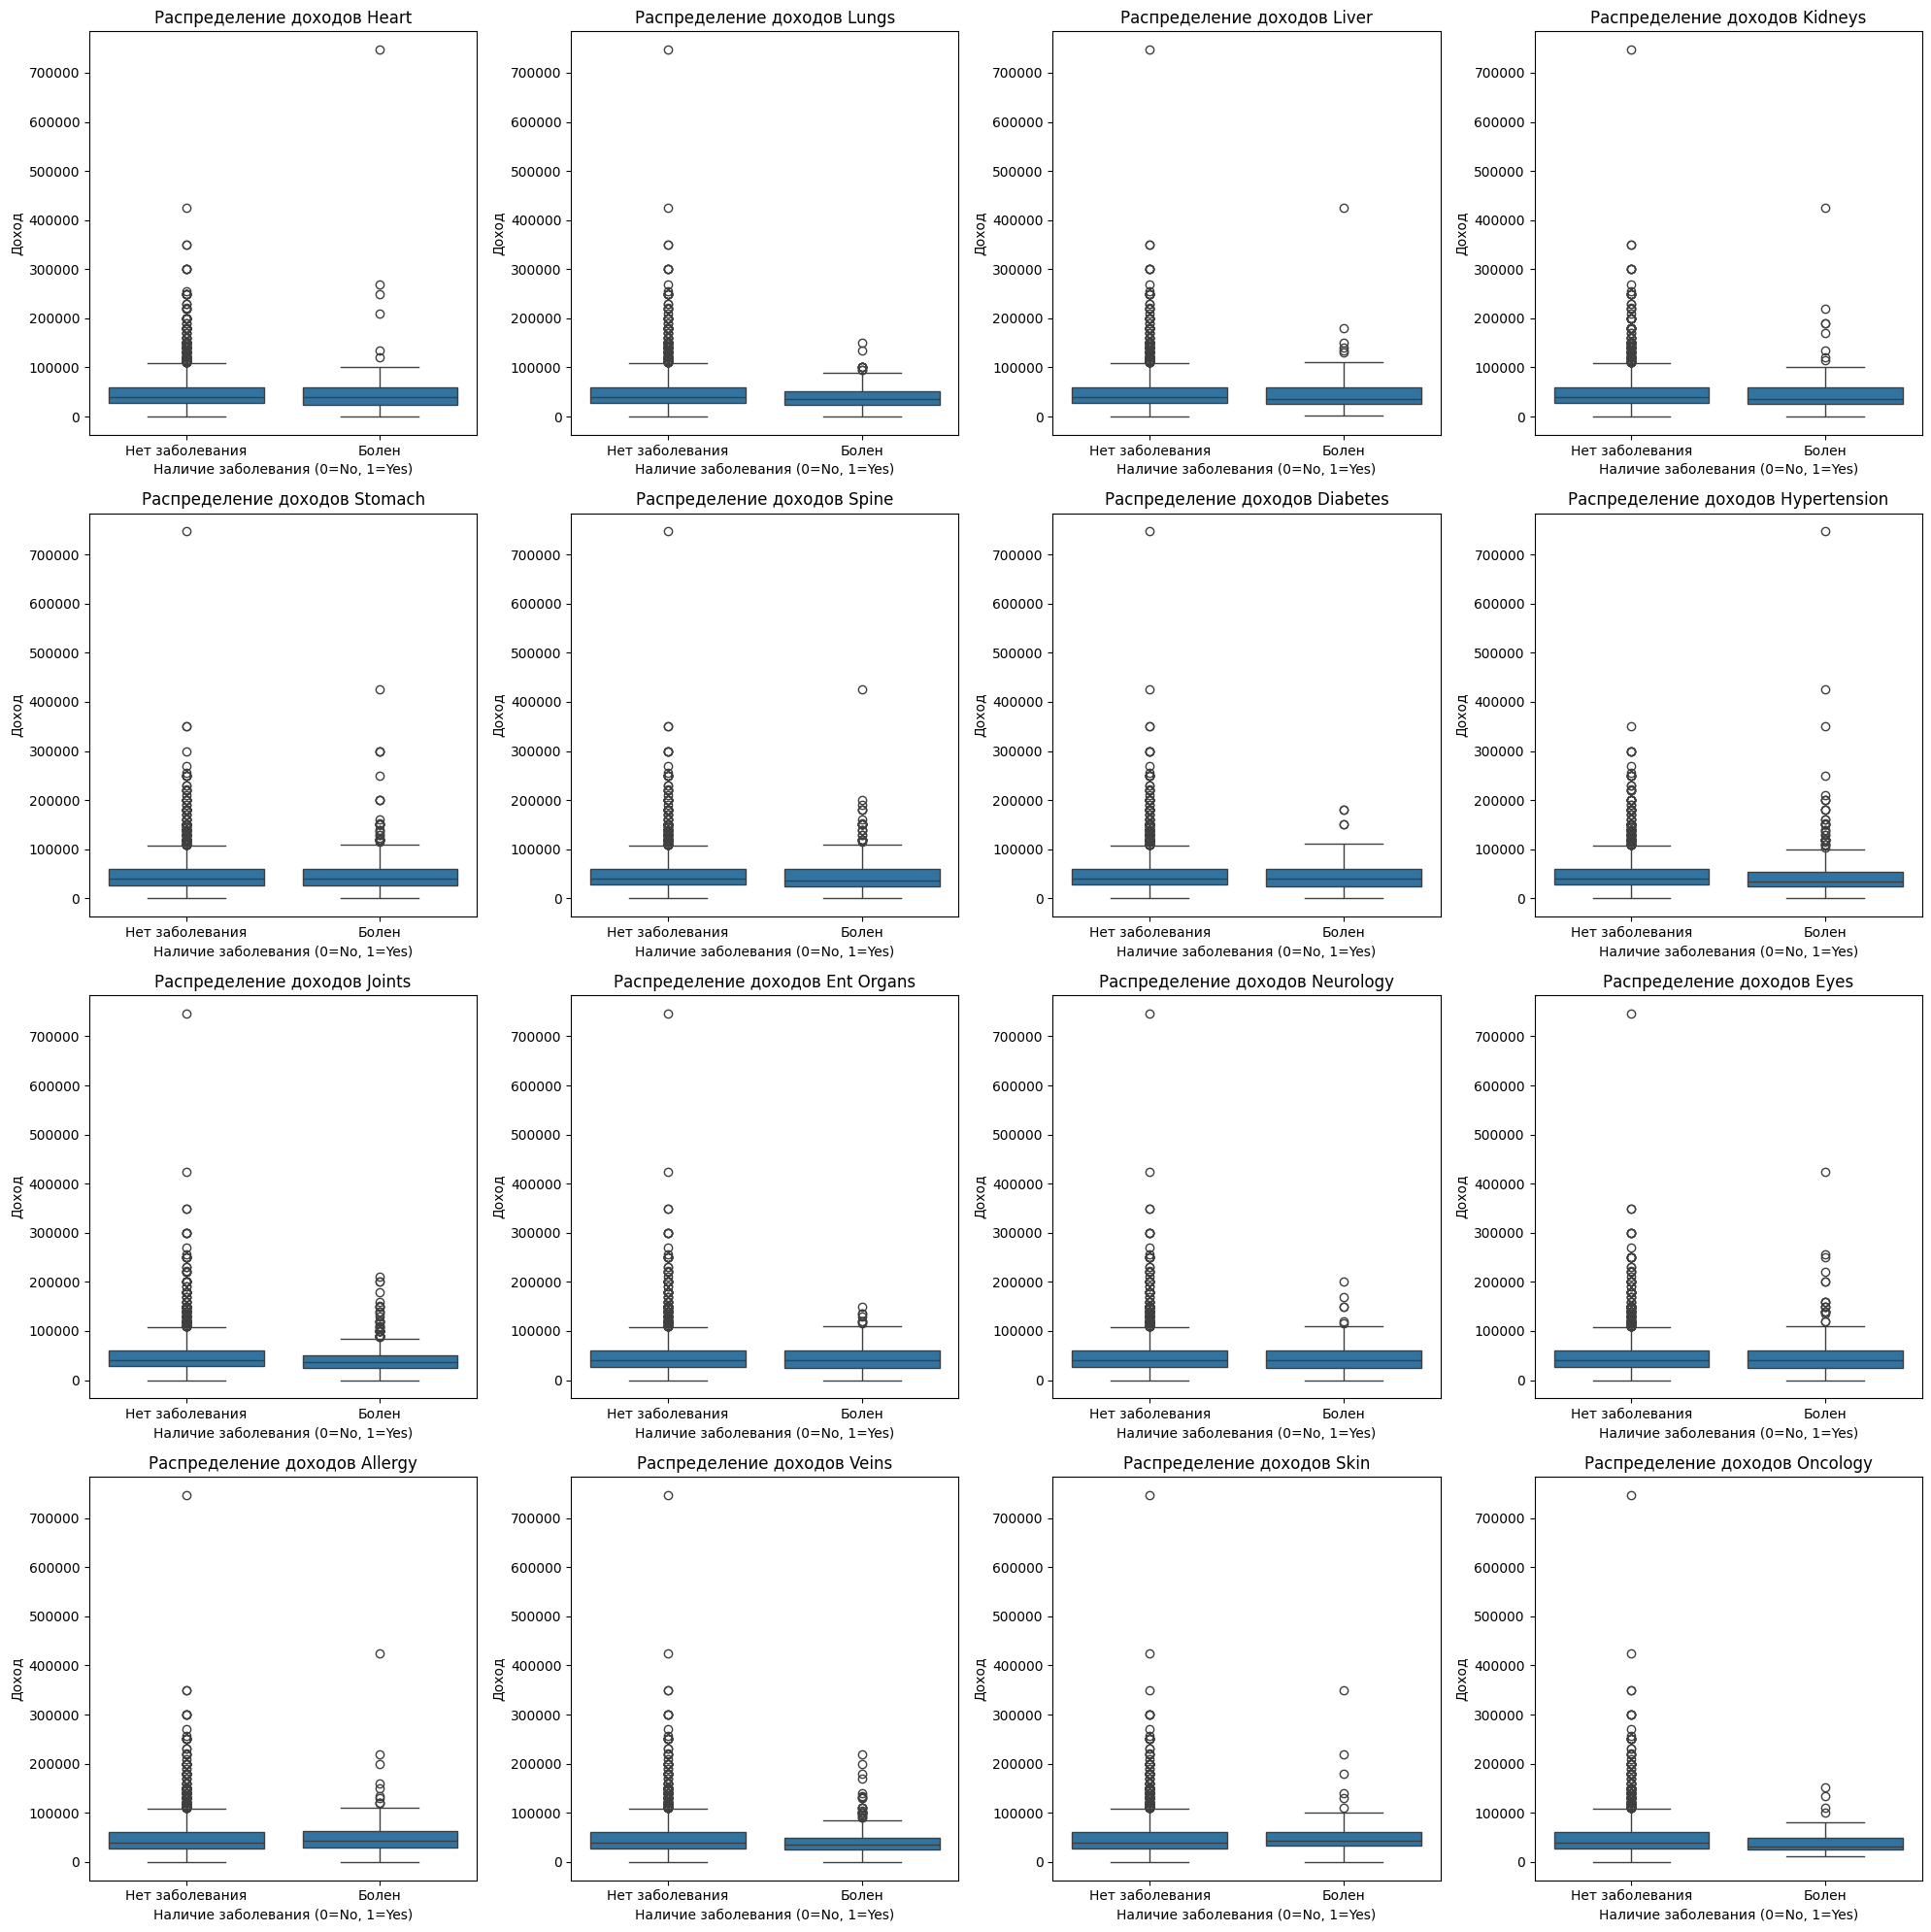

In [22]:
fig_income, axes_income = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes_income = axes_income.flatten()

for i, disease in enumerate(targets):
    sns.boxplot(x=df[disease], y=df['income'], ax=axes_income[i])
    axes_income[i].set_title(f'Распределение доходов {disease.replace("_", " ").title()}')
    axes_income[i].set_xlabel('Наличие заболевания (0=No, 1=Yes)')
    axes_income[i].set_ylabel('Доход')
    axes_income[i].set_xticks([0, 1], ['Нет заболевания', 'Болен'])

plt.tight_layout()
plt.show()

Кажется, содержательности в данном случае крайне мало.

## Pivot-таблицы


При необходимости, для более подробного рассмотрения расрпостраненности частот, можно воспользоваться этими табличками, где представлена и группировка по возрастным категориям + полу, а также по типу населенного пункта + наличие диплома.

### Таблица по возрастным группам + по полу

In [14]:
bins = [0, 18, 35, 60, df['age'].max()]
labels = ['0-18', '19-35', '36-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print(df[['age', 'age_group']].head())

    age age_group
0  44.0     36-60
1  61.0       60+
2  55.5     36-60
3  40.5     36-60
4  55.0     36-60


In [15]:
pivot_sex_age = pd.pivot_table(df, values=targets, index=['sex', 'age_group'], aggfunc='mean', observed=False)
print("Pivot-таблица показывающая распространенность заболеваний по возрастным группам и по полу:")
pivot_sex_age

Pivot-таблица показывающая распространенность заболеваний по возрастным группам и по полу:


ENT_organs   allergy  diabetes      eyes     heart  \
sex age_group                                                       
1.0 19-35        0.048000  0.052000  0.024000  0.040000  0.024000   
    36-60        0.061592  0.050519  0.026990  0.068512  0.045675   
    60+          0.030303  0.043290  0.112554  0.151515  0.134199   
2.0 19-35        0.068404  0.065147  0.013029  0.078176  0.003257   
    36-60        0.092511  0.084679  0.069506  0.115516  0.034753   
    60+          0.074766  0.077882  0.202492  0.218069  0.121495   

               hypertension    joints   kidneys     liver     lungs  \
sex age_group                                                         
1.0 19-35          0.048000  0.032000  0.004000  0.000000  0.036000   
    36-60          0.176471  0.119031  0.029066  0.036678  0.044291   
    60+            0.441558  0.281385  0.047619  0.060606  0.103896   
2.0 19-35          0.039088  0.039088  0.045603  0.003257  0.022801   
    36-60          0.207048  0.146353  0.052374  0.030348  0.057269   
    60+            0.554517  0.398754  0.071651  0.074766  0.118380   

               neurology  oncology      skin     spine   stomach     veins  
sex age_group                                                               
1.0 19-35       0.016000  0.000000  0.004000  0.060000  0.080000  0.020000  
    36-60       0.028374  0.003460  0.019377  0.136332  0.152941  0.029066  
    60+         0.060606  0.008658  0.021645  0.281385  0.199134  0.077922  
2.0 19-35       0.016287  0.000000  0.013029  0.081433  0.091205  0.029316  
    36-60       0.041605  0.011258  0.021047  0.138032  0.155653  0.099853  
    60+         0.068536  0.040498  0.015576  0.233645  0.283489  0.168224

### Таблица по типу населенного пункта + по наличию диплома

Напомню, что для type_area, 1 - городские жители, а 0 - сельские.

In [34]:
pivot_type_area_diploma = pd.pivot_table(df, values=targets, index=['type_area', 'diploma'], aggfunc='mean', observed=False)
print("Pivot-таблица со средними значениями распространенности заболеваний по типу населенного пункта и по наличию диплома:")
pivot_type_area_diploma

Pivot-таблица со средними значениями распространенности заболеваний по типу населенного пункта и по наличию диплома:


ENT_organs   allergy  diabetes      eyes     heart  \
type_area diploma                                                       
0         0.0        0.083049  0.051195  0.063709  0.056883  0.052332   
          1.0        0.079114  0.066456  0.041139  0.082278  0.053797   
1         0.0        0.071798  0.066632  0.063533  0.107955  0.043905   
          1.0        0.071575  0.081118  0.061350  0.128834  0.044990   

                   hypertension    joints   kidneys     liver     lungs  \
type_area diploma                                                         
0         0.0          0.241183  0.159272  0.039818  0.037543  0.053470   
          1.0          0.224684  0.126582  0.031646  0.022152  0.044304   
1         0.0          0.218492  0.163223  0.050620  0.035124  0.075930   
          1.0          0.188821  0.128153  0.037491  0.031357  0.034765   

                   neurology  oncology      skin     spine   stomach     veins  
type_area diploma                                                               
0         0.0       0.031854  0.010239  0.011377  0.180887  0.116041  0.058020  
          1.0       0.041139  0.009494  0.015823  0.126582  0.094937  0.050633  
1         0.0       0.035124  0.008781  0.018079  0.148244  0.182335  0.083678  
          1.0       0.042263  0.009543  0.024540  0.117928  0.162918  0.070211